# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Running best Oracle model on all Image-Datasets [2] \
[7] Running best Oracle model on all Image-Datasets with a different backbone [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [1]:
!rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perfdal.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/perfdal.db

receiving incremental file list
perfdal.db

sent 59,277 bytes  received 2,851,925 bytes  831,772.00 bytes/sec
total size is 73,830,400  speedup is 25.36


In [2]:
# Some imports and general information

import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",

    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,

    # Font settings
    #"font.family": "sans-serif",
    #"font.sans-serif": ["DejaVu Sans"],

    # Save figure settings
    "savefig.dpi": 300,
}

# Update matplotlib's global rcParams with your custom style
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#9C7AA1", "#DAB66C", "#A2D5C6", "#E699B3"])
mpl.rcParams.update({'font.family': 'serif', 'font.size': 10, 'font.weight':'normal'})

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR-10'}, 
    'stl10':{'qs':10, 'n':'STL-10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR-100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'},
    'dopanim':{'qs':25, 'n':'Dopanim'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':"#6C8EBF", 'ls':'-'},
    'badge':{'n':'BADGE', 'c':"#D45D5D", 'ls':'-'},
    'bait':{'n':'BAIT', 'c':"#5C985C", 'ls':'-'},
    'coreset':{'n':'CoreSet', 'c':"#D9822B", 'ls':'-'},
    'dropquery':{'n':'DropQuery', 'c':"#9C7AA1", 'ls':'-'},
    'margin':{'n':'Margin', 'c':"#DAB66C", 'ls':'-'},
    'random':{'n':'Random', 'c':"#A2D5C6", 'ls':'-'},
    'typiclust':{'n':'Typiclust', 'c':"#E699B3", 'ls':'-'},

    'Oracle':{'n':'BoSS', 'c':'black', 'ls':'-.'},
}

sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'dropqueryclass']
sampling_strategies_labels = ['Random', 'TypiClust', 'DropQuery', 'BAIT', 'AlfaMix', 'BADGE', 'CoreSet', 'Margin', 'TypiClust*', 'DropQuery*']

# Containers for results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Containers for results of swin model
swin_all_acc_curves_strategies = {}
swin_all_pick_choices = {}
swin_query_times = {}

# Mlflow args
uri = 'sqlite:///perfdal.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

def style_negative(v, props=''):
    return props if v.count('-') > 1 else None

def df_style(val):
    return "font-weight: bold"

In [3]:
# To read in data (removes duplicate code)
def retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True):
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    dataset = run.data.params['dataset_name']
    seed = run.data.params['random_seed']
    
    if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
        # Save Accuracies
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = {}
        if key not in all_acc_curves_strategies[dataset]:
            all_acc_curves_strategies[dataset][key] = {}
        all_acc_curves_strategies[dataset][key][seed] = accs

        # Save Query Times
        if dataset not in query_times:
            query_times[dataset] = {}
        if key not in query_times[dataset]:
            query_times[dataset][key] = {}
        query_times[dataset][key][seed] = qts

        # Save Pick Choices
        if get_pick_choices:
            pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])
    
    return all_acc_curves_strategies, query_times, all_pick_choices

In [22]:
# Plotting functions for a pairwise comparison in one dset, averaged over all dsets and a global comparison
def plot_learning_curves(all_acc_curves_strategies, strats, dsets, query_strategies, datasets, baseline="random", nrows=1, ncols=2, figsize=(10,4), only_tables=False, legend_dist=1.225, 
                         title_y=1., title_x=1., title_pad=14., save_dir=None):
    if not only_tables:
        fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, tight_layout=True)
    auc_values_rel = {}
    final_acc_rel = {}
    auc_values_abs = {}
    final_acc_abs = {}
    auc_values_abs_mean = {}
    auc_values_abs_std = {}
    for i, dset in enumerate(dsets):
        auc_values_rel[dset] = {}
        final_acc_rel[dset] = {}
        auc_values_abs[dset] = {}
        final_acc_abs[dset] = {}
        auc_values_abs_mean[dset] = {}
        auc_values_abs_std[dset] = {}

        rand_accs = list(all_acc_curves_strategies[dset][baseline].values()) 
        avg_rand_accs = np.mean(rand_accs, axis=0)
        rand_auc = np.mean(rand_accs, axis=1) * 100
        rand_final_accs = [ac[-1]*100 for ac in rand_accs]
        rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc) / np.sqrt(rand_auc.shape[0])
        rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs) / np.sqrt(len(rand_final_accs))
        auc_values_rel[dset][baseline] = str(rand_auc_mean.round(2)) + '+/-' + str(rand_auc_std.round(2))
        final_acc_rel[dset][baseline] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))
        auc_values_abs[dset][baseline] = str(rand_auc_mean.round(2)) + '+/-' + str(rand_auc_std.round(2))
        final_acc_abs[dset][baseline] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))
        auc_values_abs_mean[dset][baseline] = rand_auc_mean
        auc_values_abs_std[dset][baseline] = rand_auc_std
        if not only_tables:
            if nrows == 1:
                plt.axes(ax[i])
            else:
                plt.axes(ax[i%nrows][i//nrows])
            
        n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
        for qs in all_acc_curves_strategies[dset]:
            if qs in strats:
                accs = list(all_acc_curves_strategies[dset][qs].values())
                avg_accs = np.mean(accs, axis=0)
                final_accs = [ac[-1]*100 for ac in accs]
                aucs = np.mean(accs, axis=1) * 100
                aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs) / np.sqrt(aucs.shape[0])
                final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs) / np.sqrt(len(final_accs))

                if qs != baseline:
                    auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(2)) + '+/-' + str(aucs_std.round(2))
                    final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
                    auc_values_abs[dset][qs] = str((aucs_mean).round(2)) + '+/-' + str(aucs_std.round(2))
                    final_acc_abs[dset][qs] = str((final_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
                    auc_values_abs_mean[dset][qs] = aucs_mean
                    auc_values_abs_std[dset][qs] = aucs_std
                if not only_tables:
                    plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
        if not only_tables:
            plt.xlabel('Labeled Samples')
            if i//nrows == 0:
                plt.ylabel('Accuracy Improvement (%)')
            plt.grid(True)
            plt.title(datasets[dset]['n'], loc='right', y=title_y, x=title_x, pad=title_pad)
            plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
            plt.ylim(-0.025, plt.ylim()[1])
            idx = [0, 4, 9, 14, 19]
            plt.xticks(ticks=[n_labeled_samples[i] for i in idx], labels=[n_labeled_samples[i] for i in idx])
            plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
    if not only_tables:
        handles, labels = plt.gca().get_legend_handles_labels()
        fig.legend(loc="upper center", bbox_to_anchor=(0.5, legend_dist), ncol=5, handles=handles, labels=labels)
        if save_dir:
            plt.savefig(save_dir, bbox_inches='tight')
        plt.show()
    return {
        'acc_rel':final_acc_rel,
        'acc_abs':final_acc_abs,
        'auc_rel':auc_values_rel,
        'auc_abs':auc_values_abs,
        'auc_abs_mean':auc_values_abs_mean,
        'auc_abs_std':auc_values_abs_std
    }



def plot_auc_table(auc_mean, auc_std, baseline=None):
    # Get union of all models and datasets
    all_datasets = sorted(set(auc_mean.keys()) | set(auc_std.keys()))
    all_models = sorted({model for dataset in (auc_mean | auc_std).values() for model in dataset})

    # Move Baseline on top if given
    if baseline:
        all_models.remove(baseline)
        all_models = [baseline] + all_models

    # Create the DataFrame
    df = pd.DataFrame(index=all_models, columns=all_datasets)

    # Fill with formatted mean ± std
    for dataset in all_datasets:
        for model in all_models:
            mean = auc_mean.get(dataset, {}).get(model, None)
            std = auc_std.get(dataset, {}).get(model, None)
            if mean is not None and std is not None:
                df.loc[model, dataset] = f"{mean:.3f} ± {std:.3f}"
            else:
                df.loc[model, dataset] = "N/A"
    if baseline:
        # Build a DataFrame of styles (same shape)
        def style_func(df):
            styles = pd.DataFrame('', index=df.index, columns=df.columns)
            for row_label in df.index:
                for col_label in df.columns:
                    if row_label != baseline:
                        current = auc_mean[col_label][row_label]
                        baseline_val = auc_mean[col_label][baseline]
                        if current < baseline_val:
                            styles.loc[row_label, col_label] = 'color: red'
            return styles
        df = df.style.apply(style_func, axis=None)

        # Also make baseline row bold
        baseline_row = pd.IndexSlice[df.index[df.index == baseline], :]
        df = df.map(df_style, subset=baseline_row)
    # Show table
    display(df)
    return None


def plot_global_pairwise_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=strategies, columns=strategies)
    for strat1 in strategies:
        for strat2 in strategies:
            if strat1 == strat2:
                win_rates.loc[strat1, strat2] = 0.0
            else:
                accs1, accs2 = [], []
                for dset in dsets:
                    for key in results[dset][strat1]:
                        accs1.append(results[dset][strat1][key])
                        accs2.append(results[dset][strat2][key])
                means1 = np.mean(accs1, axis=1)
                means2 = np.mean(accs2, axis=1)

                assert means1.shape == means2.shape, f'On {dset}, {strat1} and {strat2} do not have the same number of results'
                
                comparisons = means1.round(4) > means2.round(4)
                wins = np.sum(comparisons) / means1.shape[0]
                win_rates.loc[strat1, strat2] = wins
    win_rates.index = [strat.capitalize() for strat in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)
    plt.figure(figsize=figsize)
    sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels, yticklabels=Labels)
    plt.title(f"Global Pairwise Comparison")
    plt.ylabel("Challenged Strategy")
    plt.xlabel("Challenging Strategy")
    plt.tight_layout()
    plt.show() 



def plot_global_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=dsets, columns=strategies)
    for dset in dsets:
        for strat1 in strategies:
            accs1 = []
            for key in results[dset][strat1]:
                accs1.append(results[dset][strat1][key])
            means1 = np.mean(accs1, axis=1)
            comparisons = []
            for strat2 in strategies:
                if strat2 != strat1:
                    accs2 = []
                    for key in results[dset][strat1]:
                        accs2.append(results[dset][strat2][key])
                    means2 = np.mean(accs2, axis=1)
                    comparison = means1.round(4) > means2.round(4)
                    comparisons.append(comparison)
            comp = np.prod(comparisons, axis=0)
            wins = np.sum(comp) / means1.shape[0]
            win_rates.loc[dset, strat1] = wins

    win_rates.index = [dset.capitalize() for dset in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)

    plt.figure(figsize=figsize)
    plt.title(f"Highest AUC per Dataset (%)")
    sns.heatmap(win_rates.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels)
    plt.ylabel("Dataset")
    plt.xlabel("Strategy")
    plt.tight_layout()
    plt.show()



def plot_average_pick_choices(all_pick_choices, fig_strats, fig_dsets, sampling_strategies, figsize=(12, 5), cmap = 'viridis', n_queries = 20, title=None, set_xticks=True, y_labels=None, save_dir=None):
    n_plots = len(fig_dsets) * len(fig_strats)

    fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=figsize, width_ratios=[1 for _ in range(n_plots)]+ [.2])
    if title:
        fig.suptitle("Average Pick Choice")
    
    imshows = []
    vmin, vmax = 1, 0
    for a, dset in enumerate(fig_dsets):
        for b, strat in enumerate(fig_strats):     
            j = a + b * len(fig_dsets)
            
            image = []
            for sampl_strat in sampling_strategies:
                img = []
                for seed in range(1, 7):
                    seed = str(seed)
                    im = []
                    for i in range(1, n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and all_pick_choices[dset][strat][seed][sampl_strat] != []:
                            im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

            c1 = ax[j].imshow(img_avg, cmap=cmap)
            imshows.append(c1)

            for (i, k), val in np.ndenumerate(img_avg):
                ax[j].text(k, i, f"{val:.2f}" if f"{val:.2f}" != "0.00" else "X", ha='center', va='center', color='white')
            if set_xticks:
                ax[j].set_xticks(ticks=[0], labels=[strat], rotation=25)
            else:
                ax[j].set_xticks(ticks=[], labels=[])

            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies if not y_labels else y_labels)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(datasets[dset]['n'], rotation=25)

    for im in imshows:
        im.set_clim(vmin, min(.5, vmax))

    fig.colorbar(im, cax=ax[-1], label='Relative Pick Frequency')
    if save_dir:
        plt.savefig(save_dir, bbox_inches='tight')
    plt.show()



def plot_avg_pick_choices_dset(all_pick_choices, strat, dsets, sampling_strategies, figsize=(14, 5), cmap='viridis', title=None):
    fig = plt.figure(figsize=figsize)
    if title:
        fig.suptitle(title)
    
    n_queries = 20
    images = []
    for dset in dsets:
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in all_pick_choices[dset][strat]:
                im = []
                for i in range(1, n_queries+1):
                    if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                        if i == 0:
                            im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                        else:
                            im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                    else:
                        im.append(0)
                img.append(im)
            image.append(img)
        images.append(image)
    images = np.array(images)
    img = np.mean(np.mean(images, axis=0), axis=1)

    c1 = plt.imshow(img, cmap=cmap)

    for (i, k), val in np.ndenumerate(img):
        plt.text(k, i, f"{val:.2f}" if f"{val:.2f}" != "0.00" else "X", ha='center', va='center', color='white')

    plt.xticks(ticks=range(20), labels=range(1,21), rotation=0)
    plt.yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)

    plt.title('Avg. Pick Choice over all Datasets')
    plt.colorbar(c1)
    plt.show()



def plot_pick_choices(all_pick_choices, strat, dset, sampling_strategies, figsize=(14, 5), cmap='viridis', title=None):
    fig = plt.figure(figsize=figsize)
    if title:
        fig.suptitle(title)
    
    n_queries = 20
    
    image = []
    for sampl_strat in sampling_strategies:
        img = []
        for seed in all_pick_choices[dset][strat]:
            im = []
            for i in range(1, n_queries+1):
                if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                    if i == 0:
                        im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                    else:
                        im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                else:
                    im.append(0)
            img.append(im)
        image.append(img)
    image = np.array(image)
    img = np.mean(image, axis=1)

    c1 = plt.imshow(img, cmap=cmap)

    for (i, k), val in np.ndenumerate(img):
        plt.text(k, i, f"{val:.2f}" if f"{val:.2f}" != "0.00" else "X", ha='center', va='center', color='white')

    plt.xticks(ticks=range(20), labels=range(1,21), rotation=0)
    plt.yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)

    plt.colorbar(c1)
    plt.show()

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [5]:
experiment_name = 'dinov2_baselines'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = run.data.params['al.strategy']
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=False)

experiment_name = 'dinov2_oracle'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 10)) # n_dsets * n_seeds 

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = 'Oracle'
        all_acc_curves_strategies, query_times, all_pick_choices = retrieve_data(all_acc_curves_strategies, query_times, all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### dinov2_baselines #####################################
Found 800 experiments for dinov2_baselines with expected 800 experiments.
##################################### dinov2_oracle #####################################
Found 100 experiments for dinov2_oracle with expected 100 experiments.


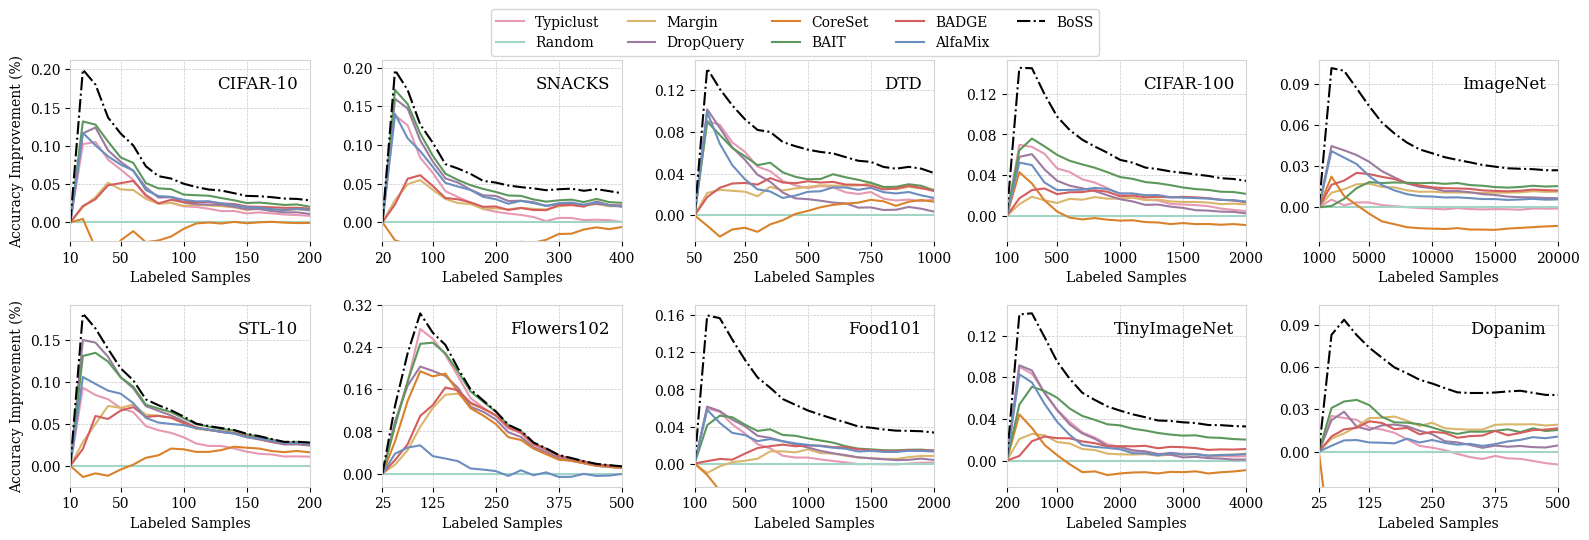

,cifar10,cifar100,dopanim,dtd,flowers102,food101,imagenet,snacks,stl10,tiny_imagenet
random,84.201 ± 0.418,66.826 ± 0.159,71.093 ± 0.258,65.301 ± 0.183,80.330 ± 0.578,67.771 ± 0.147,61.968 ± 0.026,82.170 ± 0.246,88.414 ± 0.406,63.232 ± 0.100
Oracle,90.699 ± 0.112,73.046 ± 0.089,76.221 ± 0.112,71.792 ± 0.108,90.902 ± 0.131,74.252 ± 0.103,66.433 ± 0.020,88.705 ± 0.099,95.004 ± 0.127,68.947 ± 0.057
alfamix,88.068 ± 0.206,69.123 ± 0.107,71.791 ± 0.146,68.165 ± 0.175,81.400 ± 0.569,69.867 ± 0.106,63.175 ± 0.048,86.318 ± 0.151,93.320 ± 0.491,65.104 ± 0.111
badge,86.859 ± 0.345,68.709 ± 0.087,72.482 ± 0.149,68.009 ± 0.187,87.098 ± 0.249,69.126 ± 0.107,63.470 ± 0.051,84.716 ± 0.205,92.536 ± 0.227,64.582 ± 0.094
bait,88.949 ± 0.209,70.657 ± 0.082,73.014 ± 0.202,69.274 ± 0.125,89.911 ± 0.095,70.291 ± 0.163,63.405 ± 0.046,87.337 ± 0.112,94.358 ± 0.148,66.646 ± 0.082
coreset,83.268 ± 0.683,66.817 ± 0.123,63.089 ± 0.342,65.549 ± 0.200,87.887 ± 0.115,63.338 ± 0.258,60.985 ± 0.086,79.430 ± 0.374,89.489 ± 0.206,62.885 ± 0.154
dropquery,88.038 ± 0.128,68.705 ± 0.059,72.112 ± 0.134,67.758 ± 0.120,88.519 ± 0.133,69.661 ± 0.091,63.626 ± 0.051,86.763 ± 0.145,94.299 ± 0.153,65.348 ± 0.070
margin,86.551 ± 0.339,68.227 ± 0.169,72.867 ± 0.095,67.748 ± 0.186,86.782 ± 0.356,68.414 ± 0.230,63.129 ± 0.066,84.576 ± 0.252,92.659 ± 0.207,64.202 ± 0.073
typiclust,87.338 ± 0.247,69.312 ± 0.113,71.461 ± 0.224,68.604 ± 0.149,89.734 ± 0.151,68.999 ± 0.150,61.976 ± 0.035,84.973 ± 0.127,91.919 ± 0.189,65.466 ± 0.093


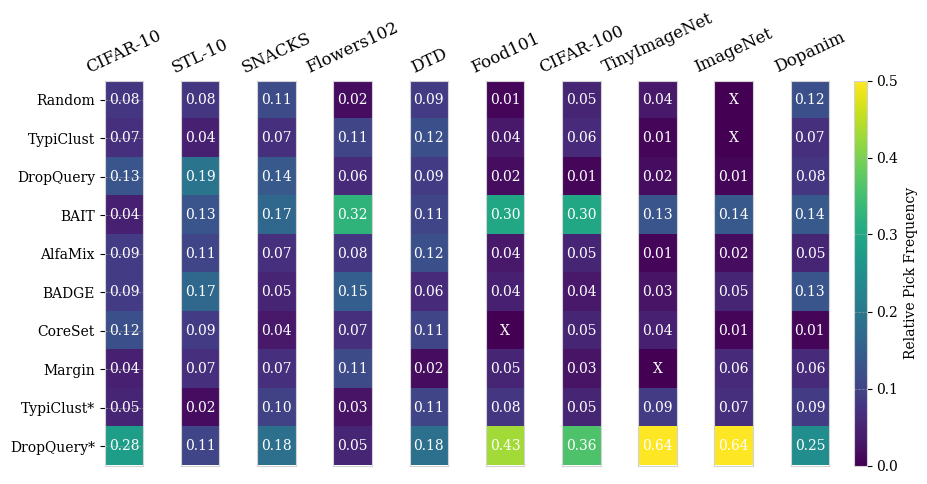

In [23]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Oracle']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets
baseline = 'random'

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(16, 5), legend_dist=1.085, 
                               title_y=0.95, title_x=0.95, title_pad=-14., save_dir='/home/phahn/repositories/dal-toolbox/publications/perf_dal/plots/learning_curves_dinov2.pdf')
auc_mean, auc_std = res_dic['auc_abs_mean'], res_dic['auc_abs_std']
plot_auc_table(auc_mean, auc_std, baseline)
plot_average_pick_choices(all_pick_choices=all_pick_choices, fig_strats=['Oracle'], fig_dsets=dsets, sampling_strategies=sampling_strategies, figsize=(10, 5), y_labels=sampling_strategies_labels,
                           set_xticks=False, save_dir='/home/phahn/repositories/dal-toolbox/publications/perf_dal/plots/avg_pick_choice_dsets_dinov2.pdf')

# Baselines + Oracle (SWIN-V2)

In [24]:
experiment_name = 'swinv2_baselines'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = run.data.params['al.strategy']
        swin_all_acc_curves_strategies, swin_query_times, swin_all_pick_choices = retrieve_data(swin_all_acc_curves_strategies, swin_query_times, swin_all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=False)

experiment_name = 'swinv2_oracle'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 10)) # n_dsets * n_seeds 

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = 'Oracle'
        swin_all_acc_curves_strategies, swin_query_times, swin_all_pick_choices = retrieve_data(swin_all_acc_curves_strategies, swin_query_times, swin_all_pick_choices, client, run, key, sampling_strategies, get_pick_choices=True)

##################################### swinv2_baselines #####################################
Found 800 experiments for swinv2_baselines with expected 800 experiments.
##################################### swinv2_oracle #####################################
Found 24 experiments for swinv2_oracle with expected 100 experiments.


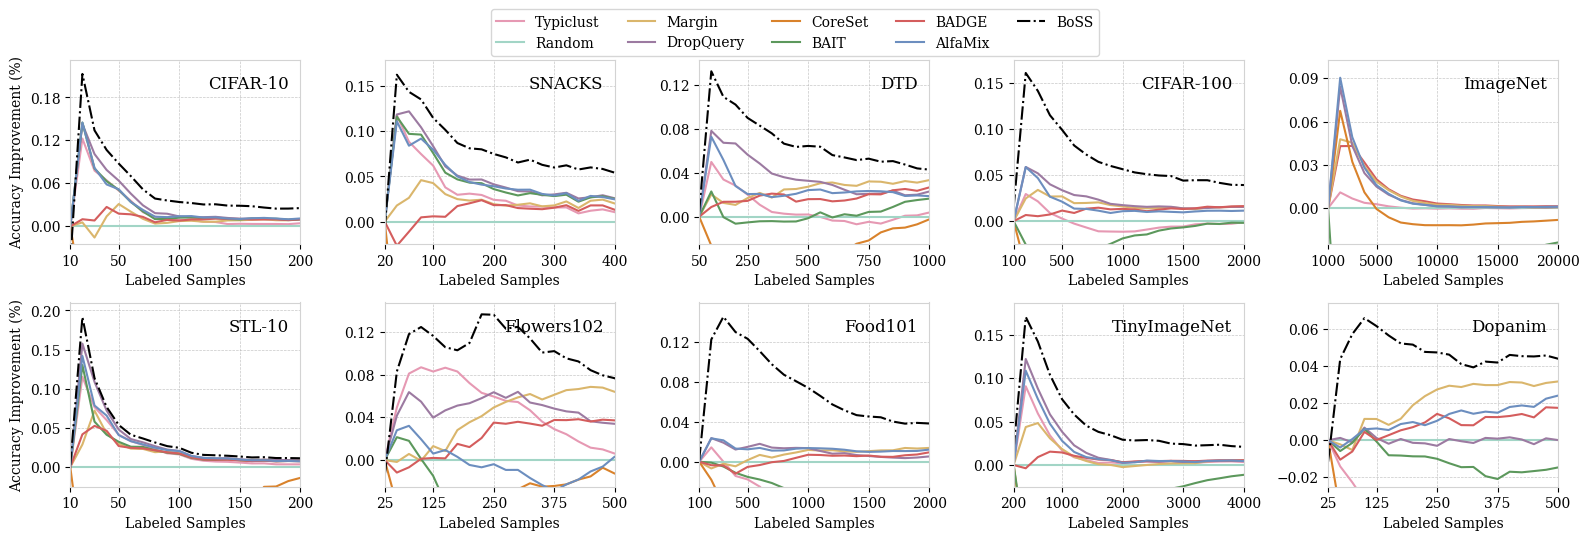

KeyError: 'Oracle'

KeyError: '4'

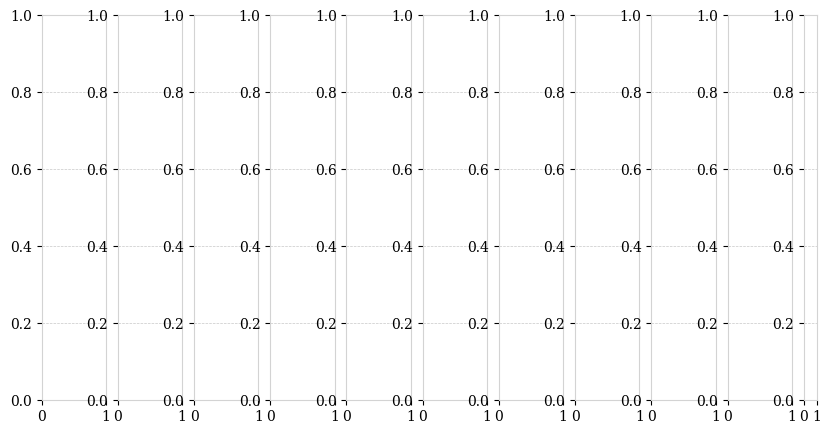

In [25]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Oracle']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets
baseline = 'random'

res_dic = plot_learning_curves(swin_all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(16, 5), legend_dist=1.085, 
                               title_y=0.95, title_x=0.95, title_pad=-14., save_dir='/home/phahn/repositories/dal-toolbox/publications/perf_dal/plots/learning_curves_swinv2.pdf')
auc_mean, auc_std = res_dic['auc_abs_mean'], res_dic['auc_abs_std']
plot_auc_table(auc_mean, auc_std, baseline)
plot_average_pick_choices(all_pick_choices=swin_all_pick_choices, fig_strats=['Oracle'], fig_dsets=dsets, sampling_strategies=sampling_strategies, figsize=(10, 5), y_labels=sampling_strategies_labels,
                           set_xticks=False, save_dir='/home/phahn/repositories/dal-toolbox/publications/perf_dal/plots/avg_pick_choice_dsets_swinv2.pdf')